# 02 — Préparation et transformation des données

Ce notebook documente toutes les étapes de preprocessing appliquées aux données brutes :

1. Chargement et audit qualité des données brutes
2. Nettoyage (valeurs manquantes, doublons, types)
3. Feature engineering (features temporelles, rolling, health score)
4. Pipeline de preprocessing sklearn (StandardScaler, OneHotEncoder)
5. Séparation train/test chronologique
6. Vérifications post-split
7. Sauvegarde des données transformées

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.feature_engineering import (
    SENSOR_COLUMNS,
    TARGET_COLUMNS,
    add_health_score,
    add_time_features,
    add_trend_features,
    build_features,
    get_model_columns,
)
from src.data.load_data import load_raw_data
from src.data.preprocess import make_preprocessor, split_temporal

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Imports OK')

Imports OK


## 1. Chargement et audit qualité des données brutes

In [4]:
df_raw = load_raw_data()
print(f'Dimensions : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes')
df_raw.head()

Dimensions : 24,042 lignes x 15 colonnes


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.8100,49.5100,5.1000,23.6000,860.9000,idle,273.8000,13.9000,61.0000,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.7500,40.5800,5.3000,23.6000,899.6000,idle,273.8500,10.2000,60.9500,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.7100,49.7000,NaN,21.3000,862.7000,idle,274.1500,13.6000,60.6500,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.7600,43.0400,4.7900,22.6000,870.4000,idle,274.5500,13.4000,60.2500,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.8800,41.3900,4.4400,22.2000,881.9000,idle,274.7000,10.8000,60.1000,0,none,0


In [5]:
print('=== Types de colonnes ===')
df_raw.dtypes

=== Types de colonnes ===


timestamp                  datetime64[ns]
machine_id                          int64
machine_type                       object
vibration_rms                     float64
temperature_motor                 float64
current_phase_avg                 float64
pressure_level                    float64
rpm                               float64
operating_mode                     object
hours_since_maintenance           float64
ambient_temp                      float64
rul_hours                         float64
failure_within_24h                  int64
failure_type                       object
estimated_repair_cost               int64
dtype: object

In [6]:
print('=== Valeurs manquantes ===')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'manquantes': missing, 'pourcentage': missing_pct})
missing_df[missing_df['manquantes'] > 0]

=== Valeurs manquantes ===


,manquantes,pourcentage
vibration_rms,1000,4.1600
temperature_motor,834,3.4700
current_phase_avg,731,3.0400
pressure_level,924,3.8400
rpm,533,2.2200


In [7]:
print(f'Doublons exacts : {df_raw.duplicated().sum()}')
print(f'Plage temporelle : {df_raw["timestamp"].min()} → {df_raw["timestamp"].max()}')
print(f'Machines distinctes : {df_raw["machine_id"].nunique()}')
print(f'Types de machines : {sorted(df_raw["machine_type"].unique())}')
print(f'Modes opérationnels : {sorted(df_raw["operating_mode"].unique())}')

Doublons exacts : 0
Plage temporelle : 2024-01-01 00:00:00 → 2024-01-14 23:59:38
Machines distinctes : 20
Types de machines : ['CNC', 'Compressor', 'Pump', 'Robotic Arm']
Modes opérationnels : ['idle', 'normal', 'peak']


In [8]:
print('=== Statistiques descriptives — capteurs ===')
df_raw[SENSOR_COLUMNS].describe().T

=== Statistiques descriptives — capteurs ===


,count,mean,std,min,25%,50%,75%,max
vibration_rms,23042.0000,1.6237,1.0811,0.3500,0.8200,1.2700,2.2700,10.0000
temperature_motor,23208.0000,51.4043,12.5193,28.0000,42.6100,50.0600,59.9625,95.0000
pressure_level,23118.0000,59.0122,38.7233,10.1000,22.7000,46.3000,94.7000,206.5000
rpm,23509.0000,1144.8493,912.6710,124.1000,489.4000,856.0000,1676.0000,4098.8000
current_phase_avg,23311.0000,8.8238,5.3664,2.2000,4.6300,6.4300,13.1200,35.0000
ambient_temp,24042.0000,12.9964,2.8840,8.0000,10.5000,13.0000,15.5000,18.0000
hours_since_maintenance,24042.0000,172.6306,150.7225,0.0000,42.8700,121.6100,295.5750,575.6300


## 2. Distribution de la variable cible

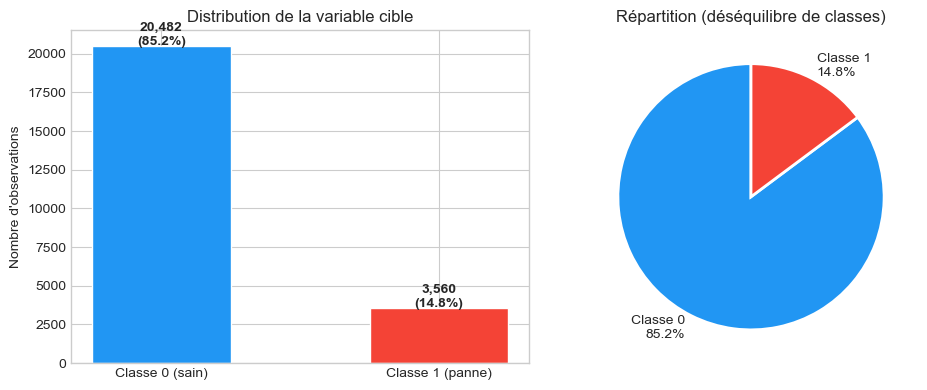

Ratio déséquilibre : 5.8:1  (négatifs/positifs)


In [9]:
target_counts = df_raw['failure_within_24h'].value_counts()
target_pct = df_raw['failure_within_24h'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Classe 0 (sain)', 'Classe 1 (panne)'], target_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
axes[0].set_title('Distribution de la variable cible')
axes[0].set_ylabel('Nombre d\'observations')
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, v + 100, f'{v:,}\n({p:.1f}%)', ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=[f'Classe 0\n{target_pct[0]:.1f}%', f'Classe 1\n{target_pct[1]:.1f}%'],
            colors=['#2196F3', '#F44336'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Répartition (déséquilibre de classes)')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Ratio déséquilibre : {target_counts[0]/target_counts[1]:.1f}:1  (négatifs/positifs)')

**Observation** : Le jeu de données est déséquilibré avec un ratio ~5.8:1 (85.2% de classe 0 contre 14.8% de classe 1).
Ce déséquilibre sera géré par :
- `class_weight="balanced"` pour les modèles sklearn
- `scale_pos_weight` pour XGBoost
- `class_weight` dictionary pour TensorFlow

## 3. Feature Engineering

### 3.1 Features temporelles

In [10]:
df_time = add_time_features(df_raw)
new_time_cols = ['hour', 'dayofweek', 'month', 'is_weekend']
print('Nouvelles colonnes temporelles :')
df_time[new_time_cols].describe().T

Nouvelles colonnes temporelles :


,count,mean,std,min,25%,50%,75%,max
hour,24042.0000,11.5509,6.9383,0.0000,6.0000,12.0000,18.0000,23.0000
dayofweek,24042.0000,2.9978,2.0163,0.0000,1.0000,3.0000,5.0000,6.0000
month,24042.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
is_weekend,24042.0000,0.2890,0.4533,0.0000,0.0000,0.0000,1.0000,1.0000


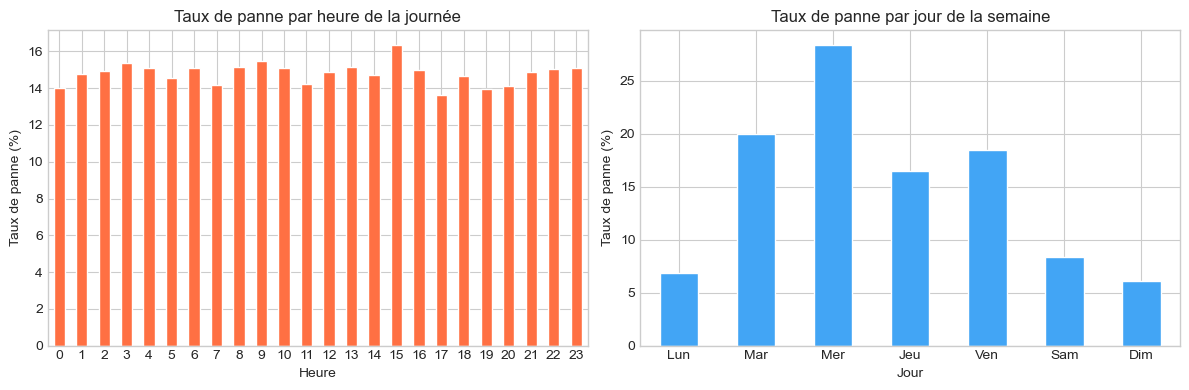

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

panne_by_hour = df_time.groupby('hour')['failure_within_24h'].mean() * 100
panne_by_hour.plot(kind='bar', ax=axes[0], color='#FF7043', edgecolor='white')
axes[0].set_title('Taux de panne par heure de la journée')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Taux de panne (%)')
axes[0].tick_params(axis='x', rotation=0)

panne_by_day = df_time.groupby('dayofweek')['failure_within_24h'].mean() * 100
day_labels = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
panne_by_day.index = day_labels
panne_by_day.plot(kind='bar', ax=axes[1], color='#42A5F5', edgecolor='white')
axes[1].set_title('Taux de panne par jour de la semaine')
axes[1].set_xlabel('Jour')
axes[1].set_ylabel('Taux de panne (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3.2 Features de tendance (rolling window = 6 observations)

In [12]:
df_trend = add_trend_features(df_time)
rolling_cols = [c for c in df_trend.columns if '_roll_mean_6' in c or '_roll_std_6' in c or '_diff_1' in c]
print(f'{len(rolling_cols)} nouvelles features rolling créées :')
for c in sorted(rolling_cols):
    print(f'  {c}')

21 nouvelles features rolling créées :
  ambient_temp_diff_1
  ambient_temp_roll_mean_6
  ambient_temp_roll_std_6
  current_phase_avg_diff_1
  current_phase_avg_roll_mean_6
  current_phase_avg_roll_std_6
  hours_since_maintenance_diff_1
  hours_since_maintenance_roll_mean_6
  hours_since_maintenance_roll_std_6
  pressure_level_diff_1
  pressure_level_roll_mean_6
  pressure_level_roll_std_6
  rpm_diff_1
  rpm_roll_mean_6
  rpm_roll_std_6
  temperature_motor_diff_1
  temperature_motor_roll_mean_6
  temperature_motor_roll_std_6
  vibration_rms_diff_1
  vibration_rms_roll_mean_6
  vibration_rms_roll_std_6


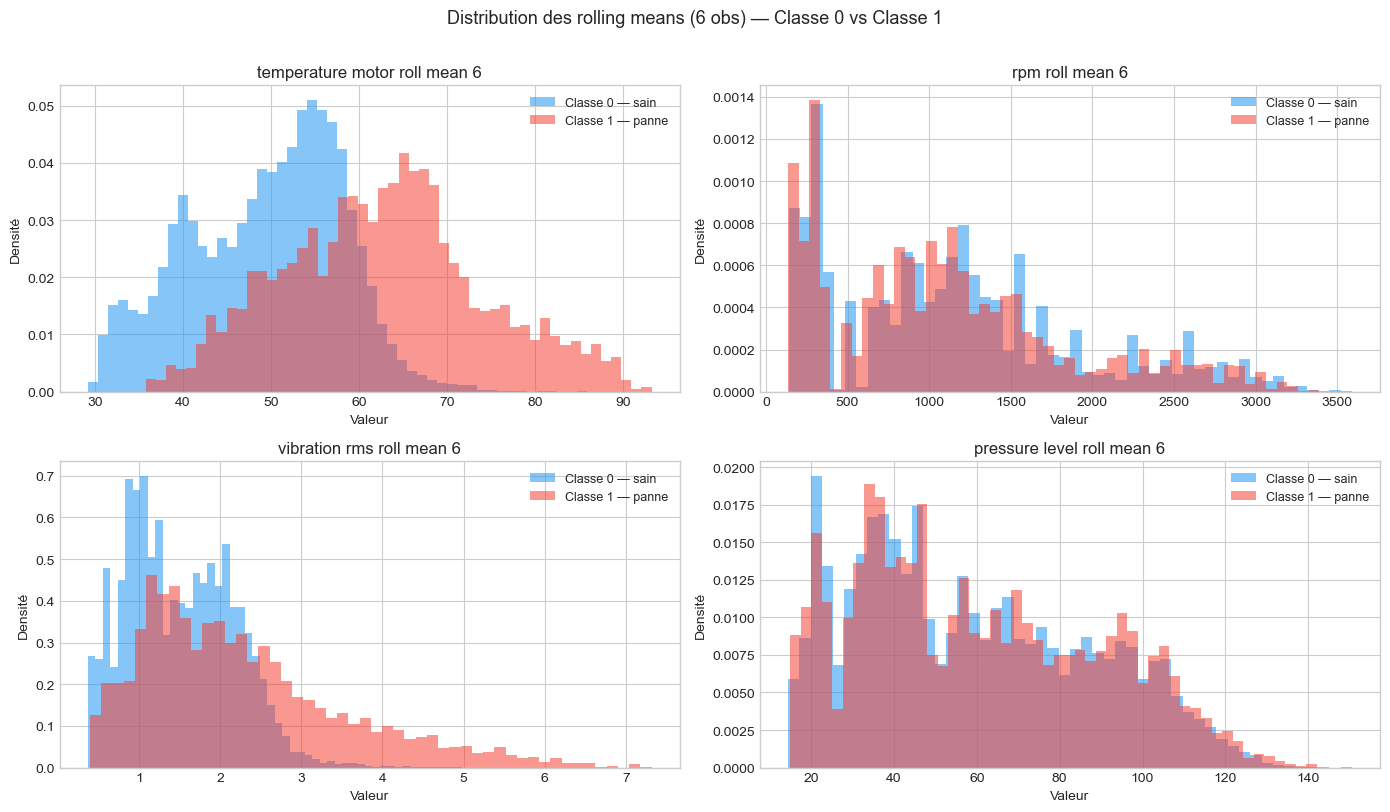

In [13]:
# Comparer les distributions des rolling mean entre classe 0 et classe 1
key_rolling = ['temperature_motor_roll_mean_6', 'rpm_roll_mean_6',
               'vibration_rms_roll_mean_6', 'pressure_level_roll_mean_6']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for i, col in enumerate(key_rolling):
    for classe, color, label in [(0, '#2196F3', 'Classe 0 — sain'), (1, '#F44336', 'Classe 1 — panne')]:
        data = df_trend[df_trend['failure_within_24h'] == classe][col].dropna()
        axes[i].hist(data, bins=50, alpha=0.55, color=color, label=label, density=True, edgecolor='none')
    axes[i].set_title(col.replace('_', ' '))
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Densité')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribution des rolling means (6 obs) — Classe 0 vs Classe 1', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'rolling_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation** : Les distributions des rolling means diffèrent clairement entre les deux classes. Les machines en état de panne imminente présentent des valeurs de température moteur et de régime moteur moyens plus élevées — ce qui justifie l'utilisation de ces features comme prédicteurs principaux.

### 3.3 Health Score composite

In [14]:
df_full = add_health_score(df_trend)
print('Health score — statistiques :')
print(df_full.groupby('failure_within_24h')['health_score'].describe())

Health score — statistiques :
                        count   mean    std    min    25%    50%    75%    max
failure_within_24h                                                            
0                  20482.0000 0.7834 0.1336 0.2066 0.6653 0.8240 0.8878 0.9926
1                   3560.0000 0.7119 0.1492 0.2474 0.5872 0.7494 0.8317 0.9695


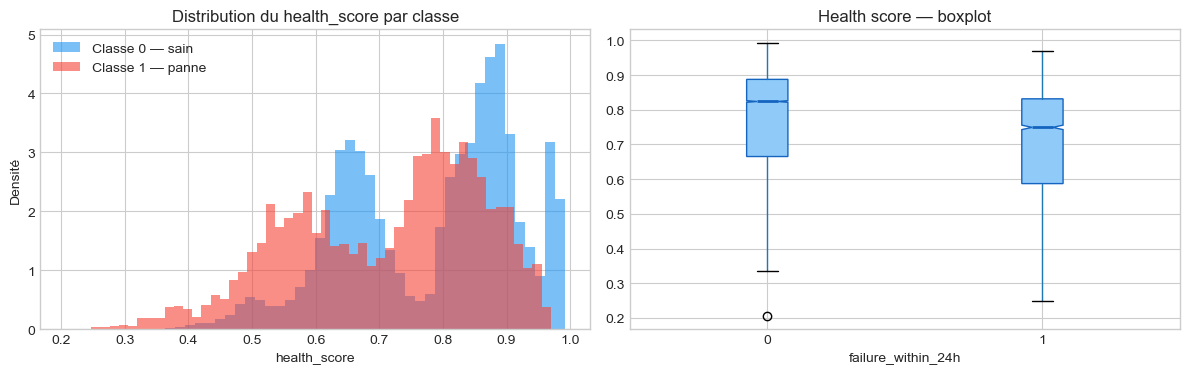


Formule : health_score = 1 - (0.30*vib + 0.25*temp + 0.20*pression + 0.15*rpm + 0.10*anomaly_trend)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for classe, color, label in [(0, '#2196F3', 'Classe 0 — sain'), (1, '#F44336', 'Classe 1 — panne')]:
    data = df_full[df_full['failure_within_24h'] == classe]['health_score'].dropna()
    axes[0].hist(data, bins=50, alpha=0.6, color=color, label=label, density=True, edgecolor='none')
axes[0].set_title('Distribution du health_score par classe')
axes[0].set_xlabel('health_score')
axes[0].set_ylabel('Densité')
axes[0].legend()

df_full.boxplot(column='health_score', by='failure_within_24h', ax=axes[1],
                 notch=True, patch_artist=True,
                 boxprops=dict(facecolor='#90CAF9', color='#1565C0'),
                 medianprops=dict(color='#1565C0', linewidth=2))
axes[1].set_title('Health score — boxplot')
axes[1].set_xlabel('failure_within_24h')
plt.suptitle('')

plt.tight_layout()
plt.show()
print(f"\nFormule : health_score = 1 - (0.30*vib + 0.25*temp + 0.20*pression + 0.15*rpm + 0.10*anomaly_trend)")

### 3.4 Récapitulatif des features construites

In [16]:
df_full_sorted = build_features(df_raw)
model_cols = get_model_columns(df_full_sorted)

print(f'Colonnes brutes   : {df_raw.shape[1]}')
print(f'Features du modèle: {len(model_cols)}')
print()

categories = {
    'Identifiants machine': [c for c in model_cols if c in ['machine_id', 'machine_type', 'operating_mode']],
    'Capteurs bruts': [c for c in model_cols if c in ['vibration_rms', 'temperature_motor', 'current_phase_avg',
                                                        'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp']],
    'Features temporelles': [c for c in model_cols if c in ['hour', 'dayofweek', 'month', 'is_weekend']],
    'Rolling mean (6 obs)': [c for c in model_cols if '_roll_mean_6' in c],
    'Rolling std (6 obs)': [c for c in model_cols if '_roll_std_6' in c],
    'Différences instantanées': [c for c in model_cols if '_diff_1' in c],
    'Scores composites': [c for c in model_cols if c in ['anomaly_trend', 'health_score']],
}

for cat, cols in categories.items():
    print(f'{cat} ({len(cols)}) : {cols}')

Colonnes brutes   : 15
Features du modèle: 36

Identifiants machine (2) : ['machine_type', 'operating_mode']
Capteurs bruts (7) : ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp']
Features temporelles (4) : ['hour', 'dayofweek', 'month', 'is_weekend']
Rolling mean (6 obs) (7) : ['vibration_rms_roll_mean_6', 'temperature_motor_roll_mean_6', 'pressure_level_roll_mean_6', 'rpm_roll_mean_6', 'current_phase_avg_roll_mean_6', 'ambient_temp_roll_mean_6', 'hours_since_maintenance_roll_mean_6']
Rolling std (6 obs) (7) : ['vibration_rms_roll_std_6', 'temperature_motor_roll_std_6', 'pressure_level_roll_std_6', 'rpm_roll_std_6', 'current_phase_avg_roll_std_6', 'ambient_temp_roll_std_6', 'hours_since_maintenance_roll_std_6']
Différences instantanées (7) : ['vibration_rms_diff_1', 'temperature_motor_diff_1', 'pressure_level_diff_1', 'rpm_diff_1', 'current_phase_avg_diff_1', 'ambient_temp_diff_1', 'hours_since_maintenance_d

## 4. Pipeline de preprocessing sklearn

In [17]:
X_train_all, X_test_all, y_train, y_test = split_temporal(df_full_sorted, target='failure_within_24h')

X_train = X_train_all[model_cols]
X_test = X_test_all[model_cols]

print(f'Train : {X_train.shape[0]:,} obs | Test : {X_test.shape[0]:,} obs')
print(f'Taux positifs — Train : {y_train.mean():.3%} | Test : {y_test.mean():.3%}')

Train : 19,233 obs | Test : 4,809 obs
Taux positifs — Train : 16.950% | Test : 6.238%


In [18]:
preprocessor = make_preprocessor(X_train)

# Identifier les colonnes numériques et catégorielles
cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()

print(f'Colonnes numériques ({len(num_cols)}) : {num_cols}')
print()
print(f'Colonnes catégorielles ({len(cat_cols)}) : {cat_cols}')

Colonnes numériques (34) : ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'hour', 'dayofweek', 'month', 'is_weekend', 'vibration_rms_roll_mean_6', 'vibration_rms_roll_std_6', 'vibration_rms_diff_1', 'temperature_motor_roll_mean_6', 'temperature_motor_roll_std_6', 'temperature_motor_diff_1', 'pressure_level_roll_mean_6', 'pressure_level_roll_std_6', 'pressure_level_diff_1', 'rpm_roll_mean_6', 'rpm_roll_std_6', 'rpm_diff_1', 'current_phase_avg_roll_mean_6', 'current_phase_avg_roll_std_6', 'current_phase_avg_diff_1', 'ambient_temp_roll_mean_6', 'ambient_temp_roll_std_6', 'ambient_temp_diff_1', 'hours_since_maintenance_roll_mean_6', 'hours_since_maintenance_roll_std_6', 'hours_since_maintenance_diff_1', 'anomaly_trend', 'health_score']

Colonnes catégorielles (2) : ['machine_type', 'operating_mode']


In [19]:
# Ajuster et transformer les données d'entraînement
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f'Shape avant preprocessing : {X_train.shape}')
print(f'Shape après preprocessing : {X_train_transformed.shape}  (OneHotEncoding des catégorielles)')
print(f'\nValeurs manquantes dans X_train transformé : {np.isnan(X_train_transformed).sum()}')
print(f'Valeurs manquantes dans X_test transformé  : {np.isnan(X_test_transformed).sum()}')

Shape avant preprocessing : (19233, 36)
Shape après preprocessing : (19233, 41)  (OneHotEncoding des catégorielles)

Valeurs manquantes dans X_train transformé : 0
Valeurs manquantes dans X_test transformé  : 0


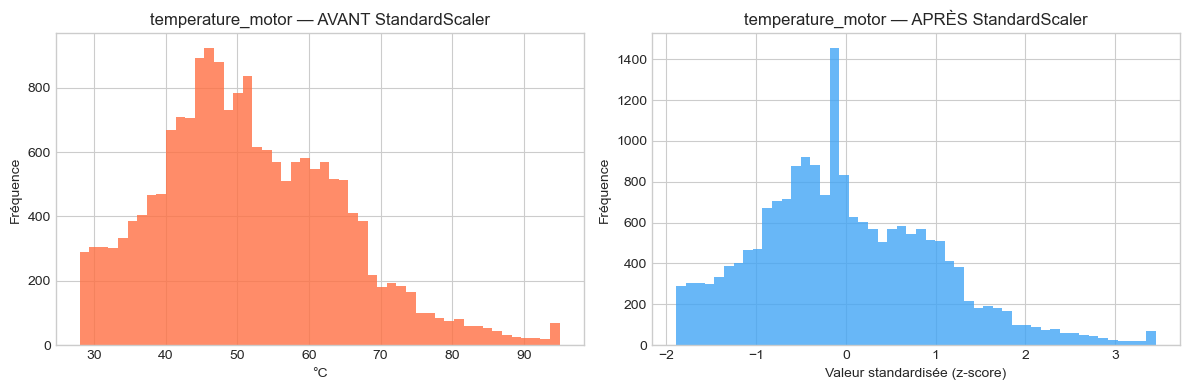

In [20]:
# Visualiser l'effet de la standardisation sur la température moteur
temp_idx = num_cols.index('temperature_motor') if 'temperature_motor' in num_cols else 0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train['temperature_motor'].dropna(), bins=50,
             color='#FF7043', edgecolor='none', alpha=0.8)
axes[0].set_title('temperature_motor — AVANT StandardScaler')
axes[0].set_xlabel('°C')
axes[0].set_ylabel('Fréquence')

axes[1].hist(X_train_transformed[:, temp_idx], bins=50,
             color='#42A5F5', edgecolor='none', alpha=0.8)
axes[1].set_title('temperature_motor — APRÈS StandardScaler')
axes[1].set_xlabel('Valeur standardisée (z-score)')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'standardization_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Séparation train/test chronologique

In [21]:
# Afficher la répartition temporelle du split
train_full = df_full_sorted.iloc[:len(X_train)].copy()
test_full = df_full_sorted.iloc[len(X_train):].copy()

print('=== Séparation train/test ===')
print(f'Train : {len(train_full):,} obs | {train_full["timestamp"].min()} → {train_full["timestamp"].max()}')
print(f'Test  : {len(test_full):,} obs | {test_full["timestamp"].min()} → {test_full["timestamp"].max()}')
print()
print(f'Taux de pannes — Train : {y_train.mean():.3%} | Test : {y_test.mean():.3%}')

=== Séparation train/test ===
Train : 19,233 obs | 2024-01-01 00:00:00 → 2024-01-12 05:49:36
Test  : 4,809 obs | 2024-01-12 05:49:38 → 2024-01-14 23:59:38

Taux de pannes — Train : 16.950% | Test : 6.238%


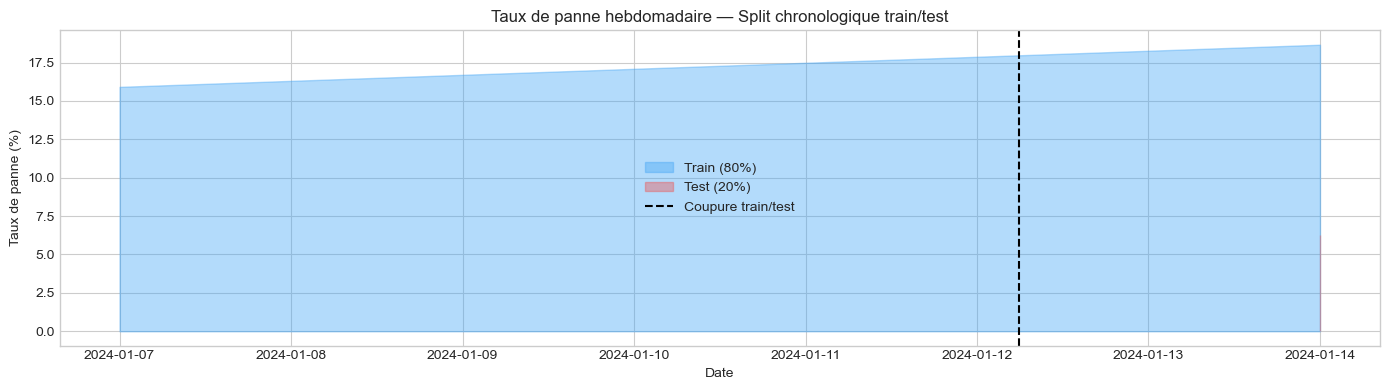

In [22]:
fig, ax = plt.subplots(figsize=(14, 4))

train_monthly = train_full.set_index('timestamp').resample('W')['failure_within_24h'].mean() * 100
test_monthly = test_full.set_index('timestamp').resample('W')['failure_within_24h'].mean() * 100

ax.fill_between(train_monthly.index, train_monthly.values, alpha=0.4, color='#42A5F5', label='Train (80%)')
ax.fill_between(test_monthly.index, test_monthly.values, alpha=0.4, color='#EF5350', label='Test (20%)')
ax.axvline(train_full['timestamp'].max(), color='black', linestyle='--', linewidth=1.5, label='Coupure train/test')
ax.set_title('Taux de panne hebdomadaire — Split chronologique train/test')
ax.set_xlabel('Date')
ax.set_ylabel('Taux de panne (%)')
ax.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

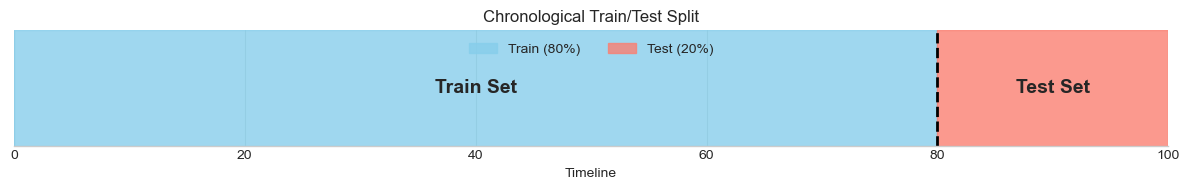

In [26]:
import matplotlib.pyplot as plt

# Taille du graphique
fig, ax = plt.subplots(figsize=(12, 2))

# Zones train/test
ax.axvspan(0, 80, color='skyblue', alpha=0.8, label='Train (80%)')
ax.axvspan(80, 100, color='salmon', alpha=0.8, label='Test (20%)')

# Ligne de séparation
ax.axvline(x=80, color='black', linestyle='--', linewidth=2)

# Texte
ax.text(40, 0.5, 'Train Set', ha='center', va='center',
        fontsize=14, fontweight='bold')

ax.text(90, 0.5, 'Test Set', ha='center', va='center',
        fontsize=14, fontweight='bold')

# Mise en forme
ax.set_xlim(0, 100)
ax.set_ylim(0, 1)

ax.set_yticks([])
ax.set_xlabel("Timeline")
ax.set_title("Chronological Train/Test Split")

# Supprimer les bordures inutiles
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

plt.legend(loc='upper center', ncol=2)
plt.tight_layout()
plt.show()

**Justification du split chronologique** : Un split aléatoire permettrait au modèle d'utiliser des observations futures pour prédire le passé (data leakage). Le split chronologique simule les conditions réelles de déploiement : le modèle ne dispose que d'informations historiques pour prédire l'avenir.

## 6. Matrice de corrélation des features clés

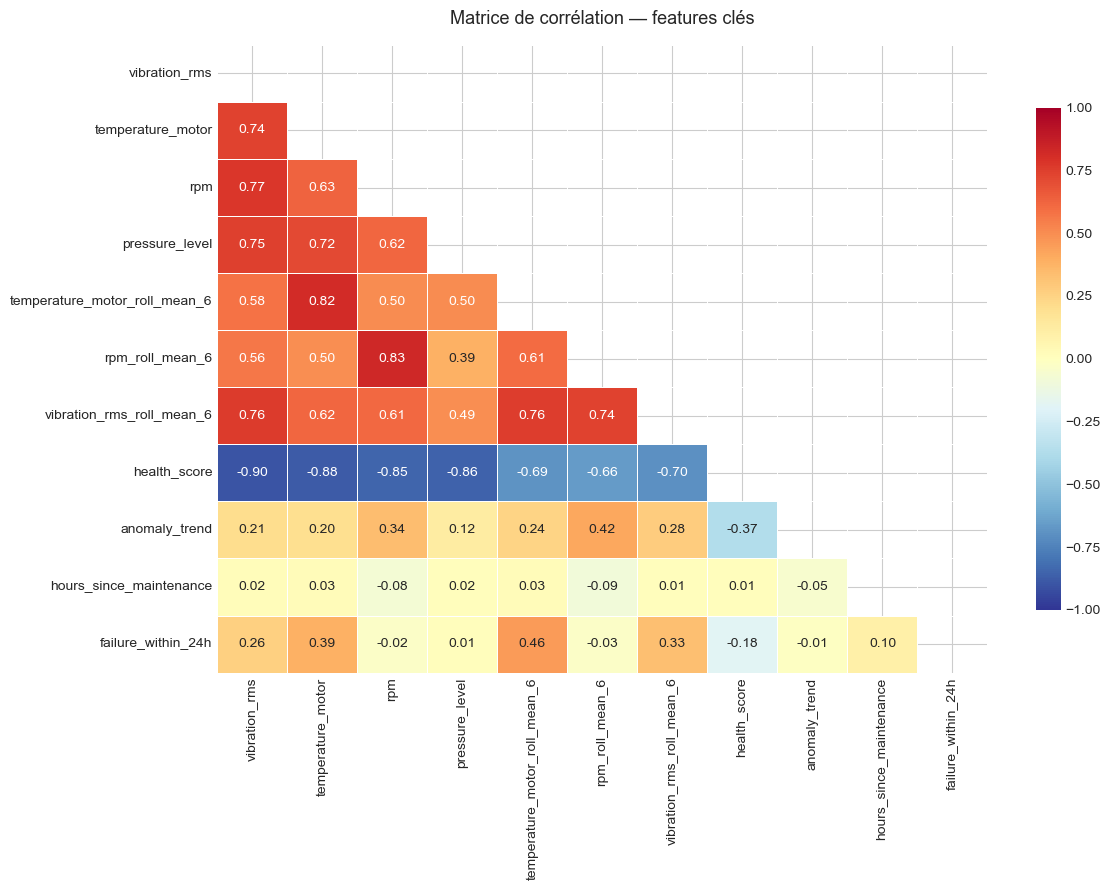

In [23]:
key_features = [
    'vibration_rms', 'temperature_motor', 'rpm', 'pressure_level',
    'temperature_motor_roll_mean_6', 'rpm_roll_mean_6',
    'vibration_rms_roll_mean_6', 'health_score', 'anomaly_trend',
    'hours_since_maintenance', 'failure_within_24h'
]
key_features = [c for c in key_features if c in df_full_sorted.columns]

corr = df_full_sorted[key_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matrice de corrélation — features clés', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Sauvegarde des données transformées

In [24]:
processed_dir = PROJECT_ROOT / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

df_full_sorted.to_csv(processed_dir / 'cleaned_data.csv', index=False)
print(f'Données sauvegardées dans {processed_dir / "cleaned_data.csv"}')
print(f'Dimensions : {df_full_sorted.shape}')

Données sauvegardées dans C:\Users\chaim\MonDossier\EFREI\2025-2026\Projet Data Science\projet_data_science_M1_EFREI\data\processed\cleaned_data.csv
Dimensions : (24042, 42)


## 8. Récapitulatif du preprocessing

In [25]:
print('=' * 60)
print('RÉCAPITULATIF DU PREPROCESSING')
print('=' * 60)
print(f'Données brutes        : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes')
print(f'Features construites  : {len(model_cols)} (après feature engineering)')
print(f'Features exclues      : failure_type, rul_hours, estimated_repair_cost')
print()
print(f'Train (80%)  : {len(X_train):,} observations')
print(f'  dont pannes: {y_train.sum():,} ({y_train.mean():.1%})')
print(f'Test  (20%)  : {len(X_test):,} observations')
print(f'  dont pannes: {y_test.sum():,} ({y_test.mean():.1%})')
print()
print(f'Colonnes numériques   : {len(num_cols)}')
print(f'Colonnes catégorielles: {len(cat_cols)} → {X_train_transformed.shape[1]} après OHE')
print()
print('Pipeline sklearn :')
print('  Numérique  : SimpleImputer(median) → StandardScaler')
print('  Catégoriel : SimpleImputer(mode)   → OneHotEncoder(handle_unknown=ignore)')

RÉCAPITULATIF DU PREPROCESSING
Données brutes        : 24,042 lignes x 15 colonnes
Features construites  : 36 (après feature engineering)
Features exclues      : failure_type, rul_hours, estimated_repair_cost

Train (80%)  : 19,233 observations
  dont pannes: 3,260 (17.0%)
Test  (20%)  : 4,809 observations
  dont pannes: 300 (6.2%)

Colonnes numériques   : 34
Colonnes catégorielles: 2 → 41 après OHE

Pipeline sklearn :
  Numérique  : SimpleImputer(median) → StandardScaler
  Catégoriel : SimpleImputer(mode)   → OneHotEncoder(handle_unknown=ignore)
